# Всероссийская студенческая Актионада – Кейс-чемпионат «РЕСТАРТ» 2025 по направлению «IT» 2 этап

## Задание 2. Прогноз ежедневного денежного остатка — на основе ATM Cash Demand Forecasting and Management

**Описание задачи:** банк/финансовая организация хочет прогнозировать, сколько наличных денег (или денежного остатка) будет необходимо или будет оставаться ежедневно, чтобы управлять ликвидностью, запасами в кассах или банкоматах. У нас есть история операций: снятия наличных, депозиты, остатки, дата (и время), день недели, флаги праздников/выходных.

**Что нужно предсказывать:** денежный остаток (или аналог — баланс, доступные средства) на конец каждого дня на горизонте 14 дней вперёд.

**Данные:**

- История операций: снятия наличных (`Total_Withdrawals`), поступления (`Total_Deposits`)
- Дата, день недели, время суток
- Календарные особенности: праздничные дни (`Holiday_Flag`), выходные (`Special_Event_Flag`)
- Место произведения операции (например, заправка, торговый центр)

**Метрики оценки качества прогнозов:**

- sMAPE (симметричная средняя абсолютная процентная ошибка)
- RMSSE (корень из среднеквадратичной ошибки скользящей шкалы)

**Задания:**

1) Интерпретируйте модель:
    - Для лучшей модели (например, LightGBM) постройте и проанализируйте график важности признаков (feature importance). Объясните, какие факторы (лаги, календарные признаки, скользящие статистики) оказывают наибольшее влияние на прогноз.
    - С помощью SHAP значений для нескольких ключевых точек времени (например, день перед праздником, понедельник) проанализируйте вклад каждого признака в итоговый прогноз.

2) Создайте отчуждаемый скрипт или сериализованный объект, который:
    - Инкапсулирует весь пайплайн: от предобработки сырых данных до генерации признаков и выполнения прогноза на 14 дней.
    - Включает в себя проверку целостности входных данных (наличие всех необходимых колонок, проверка на NaN после предобработки).
    - Логирует ключевые этапы своей работы и возможные ошибки.

3) Напишите краткую инструкцию (README), описывающую: входной формат данных, шаги для запуска пайплайна, формат выходных данных (прогноз на 14 дней) и интерпретацию результатов.


***Пояснение:*** Пункты 2 и 3 не выполнены, поскольку исследование показало непригодность данных для прогнозирования; создание пайплайна и инструкции для модели, не превосходящей константу, лишено практического смысла.

### Загрузка и обзор данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
import shap

In [2]:
try:
    df = pd.read_csv('atm_cash_management_dataset.csv')
except:
    df = pd.read_csv(r'C:\ds_projects\actionada\Task_2\atm_cash_management_dataset.csv')
df.head()

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,ATM_0041,2022-04-25,Monday,Morning,57450,9308,Standalone,0,0,112953,Rainy,5,44165
1,ATM_0007,2023-11-24,Friday,Morning,72845,17896,Supermarket,0,0,115348,Clear,0,41249
2,ATM_0014,2022-08-27,Saturday,Morning,42957,12712,Supermarket,0,0,90731,Cloudy,1,29901
3,ATM_0029,2023-08-27,Sunday,Evening,43014,1375,Mall,0,0,88754,Rainy,5,44155
4,ATM_0028,2022-12-15,Thursday,Evening,36379,2938,Bank Branch,0,0,129312,Snowy,0,29784


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5658 entries, 0 to 5657
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   ATM_ID                   5658 non-null   str  
 1   Date                     5658 non-null   str  
 2   Day_of_Week              5658 non-null   str  
 3   Time_of_Day              5658 non-null   str  
 4   Total_Withdrawals        5658 non-null   int64
 5   Total_Deposits           5658 non-null   int64
 6   Location_Type            5658 non-null   str  
 7   Holiday_Flag             5658 non-null   int64
 8   Special_Event_Flag       5658 non-null   int64
 9   Previous_Day_Cash_Level  5658 non-null   int64
 10  Weather_Condition        5658 non-null   str  
 11  Nearby_Competitor_ATMs   5658 non-null   int64
 12  Cash_Demand_Next_Day     5658 non-null   int64
dtypes: int64(7), str(6)
memory usage: 574.8 KB


In [4]:
df.describe(include='all')

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
count,5658,5658,5658,5658,5658.000000,5658.000000,5658,5658.000000,5658.000000,5658.000000,5658,5658.000000,5658.000000
unique,50,731,7,4,NaN,NaN,5,NaN,NaN,NaN,4,NaN,NaN
top,ATM_0044,2022-11-04,Monday,Afternoon,NaN,NaN,Gas Station,NaN,NaN,NaN,Clear,NaN,NaN
freq,152,16,831,1449,NaN,NaN,1144,NaN,NaN,NaN,1469,NaN,NaN
mean,NaN,NaN,NaN,NaN,49808.106928,10129.078473,NaN,0.022093,0.096501,100283.994698,NaN,2.477731,43085.207494
std,NaN,NaN,NaN,NaN,14903.539241,4878.853583,NaN,0.146998,0.295303,20122.365608,NaN,1.719487,16797.100086
min,NaN,NaN,NaN,NaN,1380.000000,0.000000,NaN,0.000000,0.000000,23266.000000,NaN,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,39469.250000,6765.000000,NaN,0.000000,0.000000,86533.500000,NaN,1.000000,31558.750000
50%,NaN,NaN,NaN,NaN,50039.000000,10048.000000,NaN,0.000000,0.000000,100276.500000,NaN,2.000000,42589.500000
75%,NaN,NaN,NaN,NaN,60132.500000,13430.000000,NaN,0.000000,0.000000,113956.500000,NaN,4.000000,53831.000000


In [5]:
df.isna().sum()

ATM_ID                     0
Date                       0
Day_of_Week                0
Time_of_Day                0
Total_Withdrawals          0
Total_Deposits             0
Location_Type              0
Holiday_Flag               0
Special_Event_Flag         0
Previous_Day_Cash_Level    0
Weather_Condition          0
Nearby_Competitor_ATMs     0
Cash_Demand_Next_Day       0
dtype: int64

In [6]:
print('Полных дубликатов в датасете:', df.duplicated().sum())

Полных дубликатов в датасете: 0


**Промежуточный вывод:** в ходе обзора данных не выявлено пропусков и дубликатов. В столбце `Date` неправильный тип данных. У столбцов с числовым типом данных (`Total_Withdrawals`, `Total_Deposits`, `Previous_Day_Cash_Level`, `Cash_Demand_Next_Day`), кроме `Nearby_Competitor_ATMs`, нормальное распределение, так как разница между минимальным значением и 25 персентилем и разница между максимальным значением и 75 персентилем примерно одинаковая и при этом намного больше, чем разница между 25, 50 и 75 персентилями.

### Предобработка данных

In [7]:
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
display(df.head())
df.dtypes

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
0,ATM_0041,2022-04-25,Monday,Morning,57450,9308,Standalone,0,0,112953,Rainy,5,44165
1,ATM_0007,2023-11-24,Friday,Morning,72845,17896,Supermarket,0,0,115348,Clear,0,41249
2,ATM_0014,2022-08-27,Saturday,Morning,42957,12712,Supermarket,0,0,90731,Cloudy,1,29901
3,ATM_0029,2023-08-27,Sunday,Evening,43014,1375,Mall,0,0,88754,Rainy,5,44155
4,ATM_0028,2022-12-15,Thursday,Evening,36379,2938,Bank Branch,0,0,129312,Snowy,0,29784


ATM_ID                                str
Date                       datetime64[us]
Day_of_Week                           str
Time_of_Day                           str
Total_Withdrawals                   int64
Total_Deposits                      int64
Location_Type                         str
Holiday_Flag                        int64
Special_Event_Flag                  int64
Previous_Day_Cash_Level             int64
Weather_Condition                     str
Nearby_Competitor_ATMs              int64
Cash_Demand_Next_Day                int64
dtype: object

In [8]:
string_cols = df.select_dtypes(include='str')
for i in string_cols:
    print(df[i].unique())

<StringArray>
['ATM_0041', 'ATM_0007', 'ATM_0014', 'ATM_0029', 'ATM_0028', 'ATM_0006',
 'ATM_0047', 'ATM_0040', 'ATM_0024', 'ATM_0045', 'ATM_0003', 'ATM_0042',
 'ATM_0048', 'ATM_0015', 'ATM_0030', 'ATM_0020', 'ATM_0050', 'ATM_0031',
 'ATM_0035', 'ATM_0034', 'ATM_0038', 'ATM_0033', 'ATM_0037', 'ATM_0004',
 'ATM_0016', 'ATM_0018', 'ATM_0027', 'ATM_0025', 'ATM_0039', 'ATM_0023',
 'ATM_0046', 'ATM_0017', 'ATM_0001', 'ATM_0036', 'ATM_0002', 'ATM_0011',
 'ATM_0013', 'ATM_0021', 'ATM_0026', 'ATM_0019', 'ATM_0010', 'ATM_0044',
 'ATM_0012', 'ATM_0022', 'ATM_0009', 'ATM_0032', 'ATM_0008', 'ATM_0049',
 'ATM_0005', 'ATM_0043']
Length: 50, dtype: str
<StringArray>
['Monday', 'Friday', 'Saturday', 'Sunday', 'Thursday', 'Wednesday', 'Tuesday']
Length: 7, dtype: str
<StringArray>
['Morning', 'Evening', 'Afternoon', 'Night']
Length: 4, dtype: str
<StringArray>
['Standalone', 'Supermarket', 'Mall', 'Bank Branch', 'Gas Station']
Length: 5, dtype: str
<StringArray>
['Rainy', 'Clear', 'Cloudy', 'Snowy']
Le

**Промежуточный вывод:** Тип данных в столбце `Date` заменён на datetime. Проверены все столбцы со строковым типом данных, на наличие неявных дубликатов или опечаток. 

### Исследовательский анализ данных

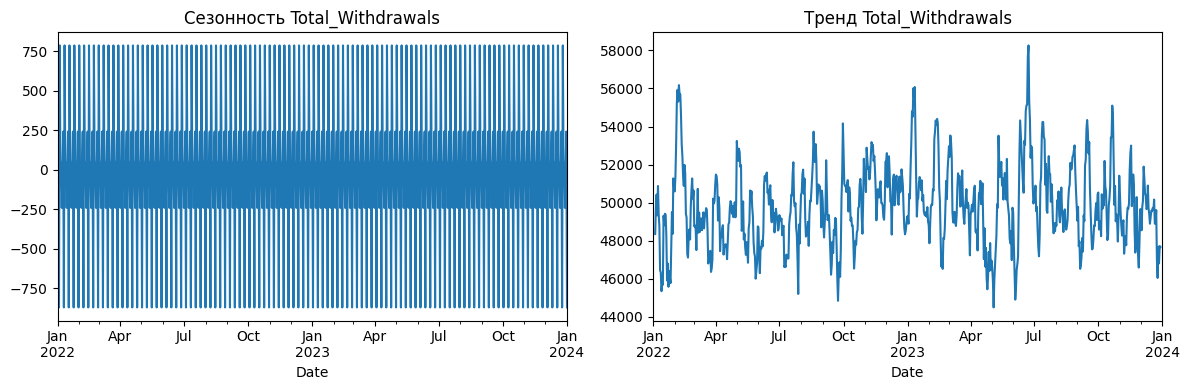

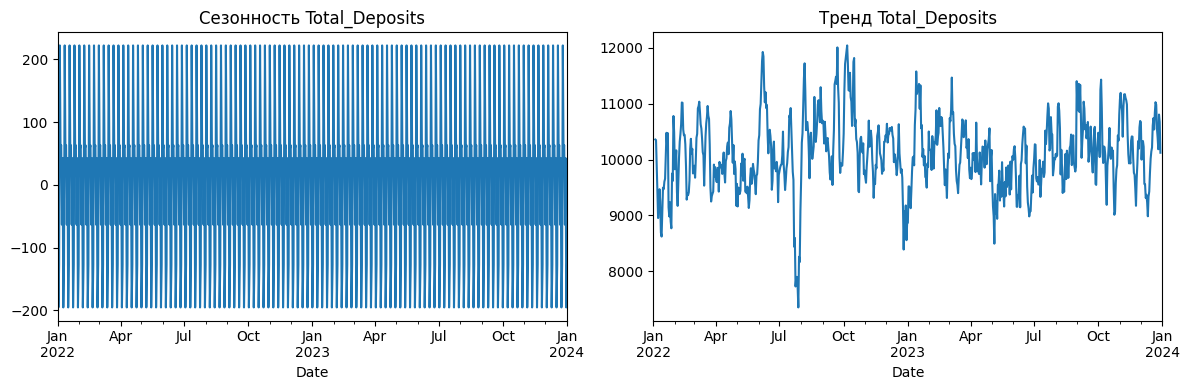

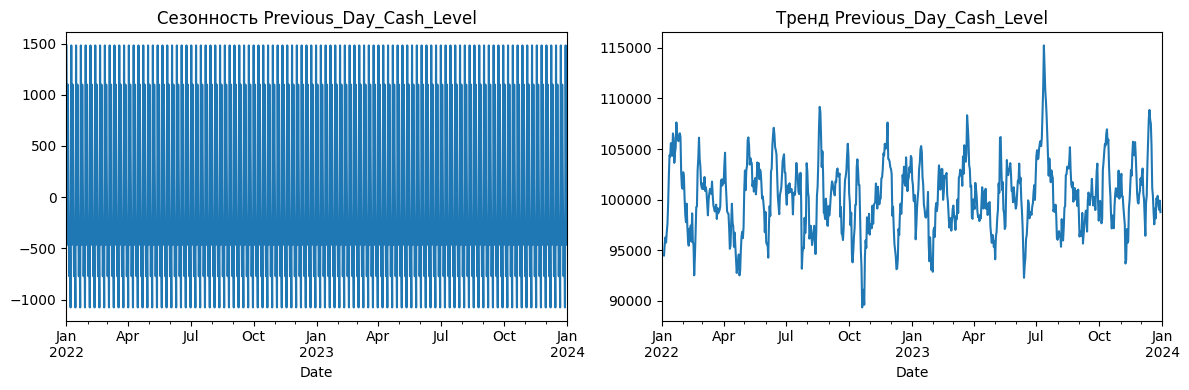

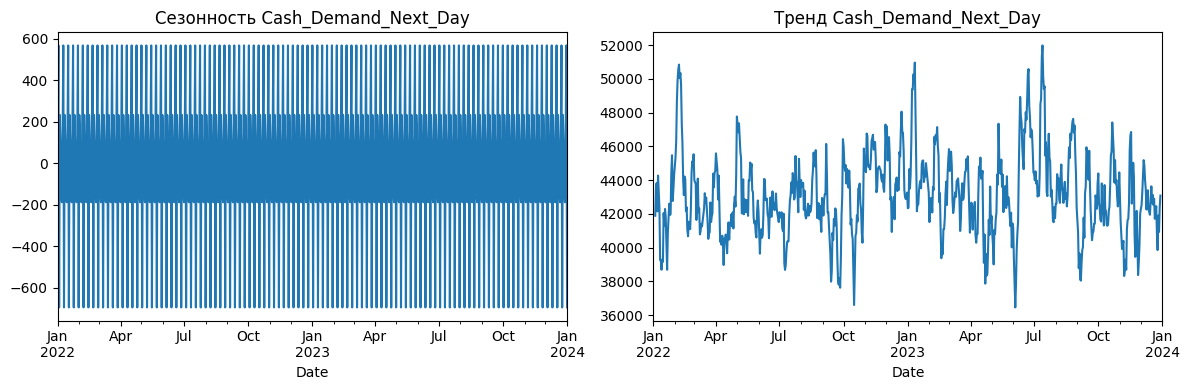

In [9]:
target_cols = ['Total_Withdrawals', 'Total_Deposits',
               'Previous_Day_Cash_Level', 'Cash_Demand_Next_Day']

for col in target_cols:
    daily = df.groupby('Date')[col].mean() 
    decomposed = seasonal_decompose(daily, period=7)  
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    decomposed.seasonal.plot(ax=axes[0], title=f'Сезонность {col}')
    decomposed.trend.plot(ax=axes[1], title=f'Тренд {col}')
    plt.tight_layout()
    plt.show()

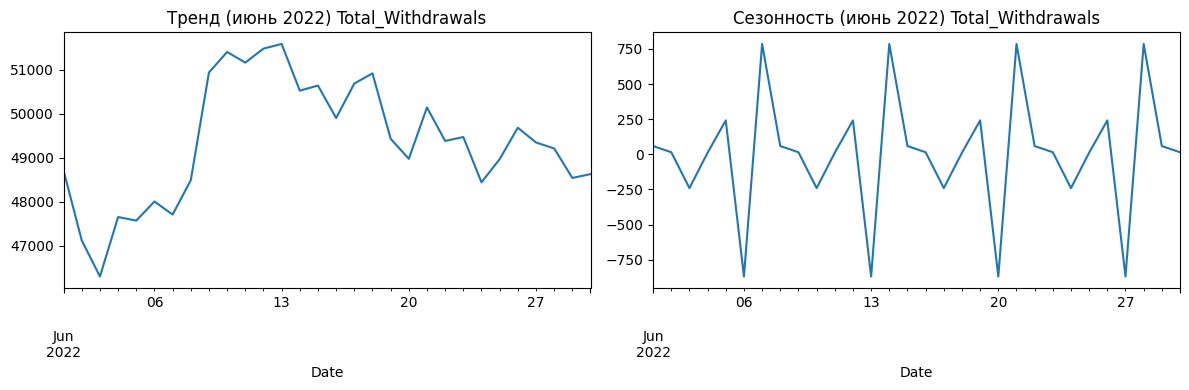

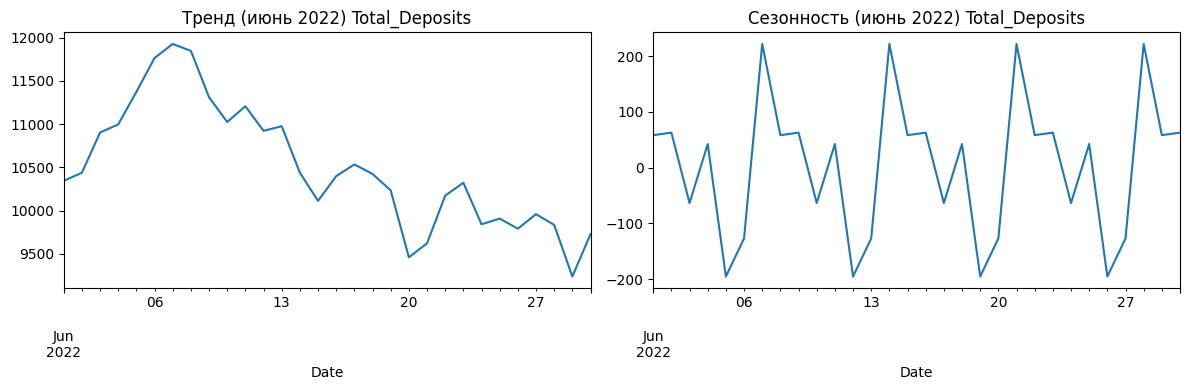

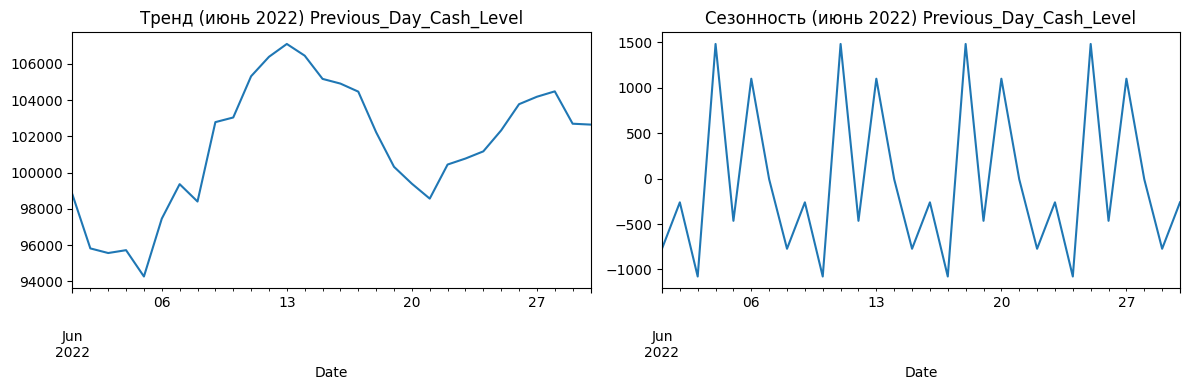

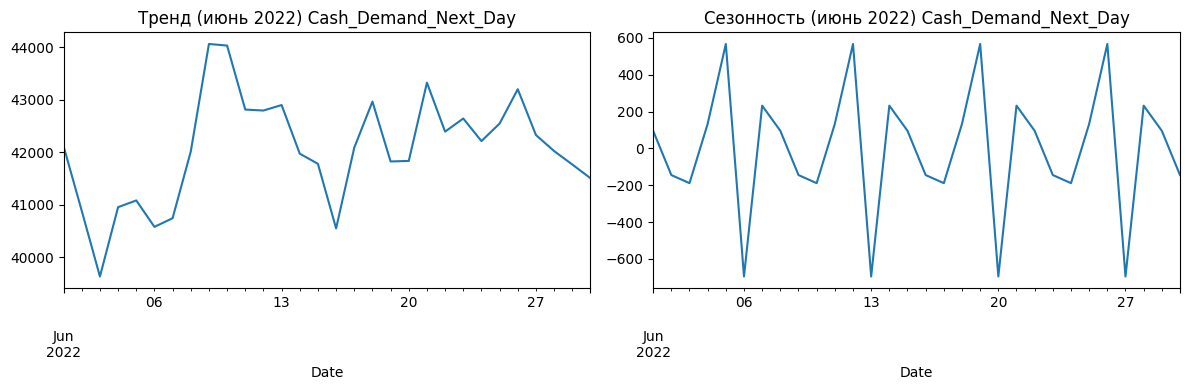

In [10]:
target_cols = ['Total_Withdrawals', 'Total_Deposits',
               'Previous_Day_Cash_Level', 'Cash_Demand_Next_Day']

for col in target_cols:
    daily = df.groupby('Date')[col].mean()
    decomposed = seasonal_decompose(daily, period=7)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    decomposed.trend.loc['2022-06-01':'2022-06-30'].plot(ax=axes[0], title=f'Тренд (июнь 2022) {col}')
    decomposed.seasonal.loc['2022-06-01':'2022-06-30'].plot(ax=axes[1], title=f'Сезонность (июнь 2022) {col}')
    plt.tight_layout()
    plt.show()

In [11]:
df.corr(numeric_only=True)

,Total_Withdrawals,Total_Deposits,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
Total_Withdrawals,1.000000,-0.000420,-0.028994,-0.004441,-0.009252,-0.012022,0.895053
Total_Deposits,-0.000420,1.000000,-0.000877,0.025669,-0.009107,0.006298,-0.213557
Holiday_Flag,-0.028994,-0.000877,1.000000,-0.008399,0.006642,-0.023580,0.019698
Special_Event_Flag,-0.004441,0.025669,-0.008399,1.000000,0.004580,0.001796,0.117524
Previous_Day_Cash_Level,-0.009252,-0.009107,0.006642,0.004580,1.000000,0.007805,-0.005849
Nearby_Competitor_ATMs,-0.012022,0.006298,-0.023580,0.001796,0.007805,1.000000,-0.014231
Cash_Demand_Next_Day,0.895053,-0.213557,0.019698,0.117524,-0.005849,-0.014231,1.000000


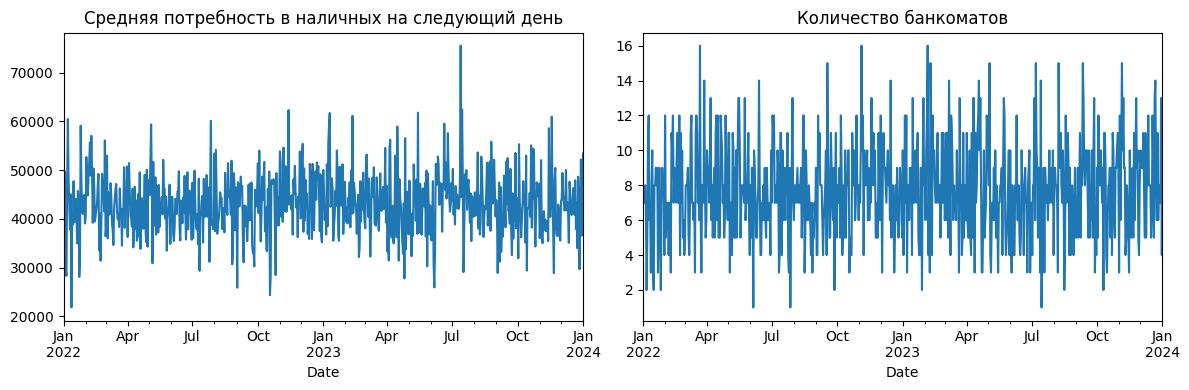

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby('Date')['Cash_Demand_Next_Day'].mean().plot(kind='line', title='Средняя потребность в наличных на следующий день', ax=axes[0])
df.groupby('Date')['ATM_ID'].count().plot(kind='line', title='Количество банкоматов', ax=axes[1])
plt.tight_layout()
plt.show()

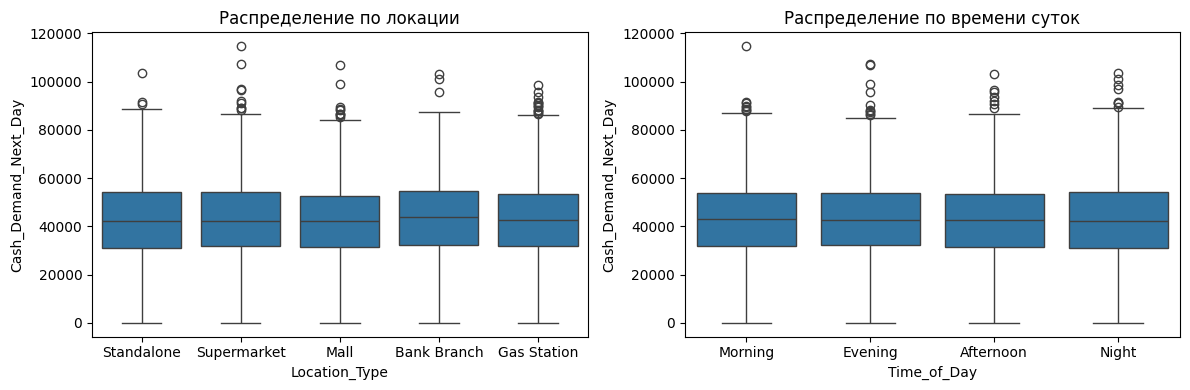

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=df, x='Location_Type', y='Cash_Demand_Next_Day', ax=axes[0]).set(title='Распределение по локации')
sns.boxplot(data=df, x='Time_of_Day', y='Cash_Demand_Next_Day', ax=axes[1]).set(title='Распределение по времени суток')
plt.tight_layout()
plt.show()

In [14]:
df.groupby('ATM_ID')['Location_Type'].nunique()

ATM_ID
ATM_0001    5
ATM_0002    5
ATM_0003    5
ATM_0004    5
ATM_0005    5
ATM_0006    5
ATM_0007    5
ATM_0008    5
ATM_0009    5
ATM_0010    5
ATM_0011    5
ATM_0012    5
ATM_0013    5
ATM_0014    5
ATM_0015    5
ATM_0016    5
ATM_0017    5
ATM_0018    5
ATM_0019    5
ATM_0020    5
ATM_0021    5
ATM_0022    5
ATM_0023    5
ATM_0024    5
ATM_0025    5
ATM_0026    5
ATM_0027    5
ATM_0028    5
ATM_0029    5
ATM_0030    5
ATM_0031    5
ATM_0032    5
ATM_0033    5
ATM_0034    5
ATM_0035    5
ATM_0036    5
ATM_0037    5
ATM_0038    5
ATM_0039    5
ATM_0040    5
ATM_0041    5
ATM_0042    5
ATM_0043    5
ATM_0044    5
ATM_0045    5
ATM_0046    5
ATM_0047    5
ATM_0048    5
ATM_0049    5
ATM_0050    5
Name: Location_Type, dtype: int64

In [15]:
df[df['ATM_ID'] == 'ATM_0001'].sort_values('Date').head(30)

,ATM_ID,Date,Day_of_Week,Time_of_Day,Total_Withdrawals,Total_Deposits,Location_Type,Holiday_Flag,Special_Event_Flag,Previous_Day_Cash_Level,Weather_Condition,Nearby_Competitor_ATMs,Cash_Demand_Next_Day
2904,ATM_0001,2022-01-05,Wednesday,Night,37573,6224,Standalone,0,1,109776,Clear,4,31478
5023,ATM_0001,2022-01-13,Thursday,Morning,48156,10070,Gas Station,0,1,113068,Clear,5,41613
4538,ATM_0001,2022-01-20,Thursday,Evening,24671,13922,Mall,0,0,118171,Rainy,4,11316
4986,ATM_0001,2022-01-28,Friday,Night,46383,12205,Mall,0,0,96931,Clear,4,34587
4064,ATM_0001,2022-02-01,Tuesday,Morning,41972,18452,Bank Branch,0,0,83257,Rainy,5,23665
2174,ATM_0001,2022-02-24,Thursday,Evening,57436,13221,Mall,0,0,86430,Snowy,1,40364
5042,ATM_0001,2022-02-27,Sunday,Night,51743,4702,Supermarket,0,0,120473,Clear,5,38910
492,ATM_0001,2022-03-05,Saturday,Afternoon,63303,7896,Bank Branch,0,0,47915,Cloudy,2,63926
3160,ATM_0001,2022-03-05,Saturday,Morning,61950,13590,Standalone,0,1,110780,Rainy,4,62604
1360,ATM_0001,2022-03-08,Tuesday,Night,54368,8182,Mall,0,1,96319,Clear,5,63865


In [16]:
print(df.groupby('Day_of_Week')['Cash_Demand_Next_Day'].std())
df.groupby('Day_of_Week')['Cash_Demand_Next_Day'].mean()

Day_of_Week
Friday       16551.184479
Monday       16131.614589
Saturday     16795.699399
Sunday       16992.188669
Thursday     17153.269375
Tuesday      16930.499856
Wednesday    17073.181132
Name: Cash_Demand_Next_Day, dtype: float64


Day_of_Week
Friday       43175.278729
Monday       42650.046931
Saturday     42809.879012
Sunday       43676.686732
Thursday     42839.079462
Tuesday      43328.164366
Wednesday    43133.503896
Name: Cash_Demand_Next_Day, dtype: float64

In [17]:
print(len(df.groupby('Date')))
df['Date'].max() - df['Date'].min()

731


Timedelta('730 days 00:00:00')

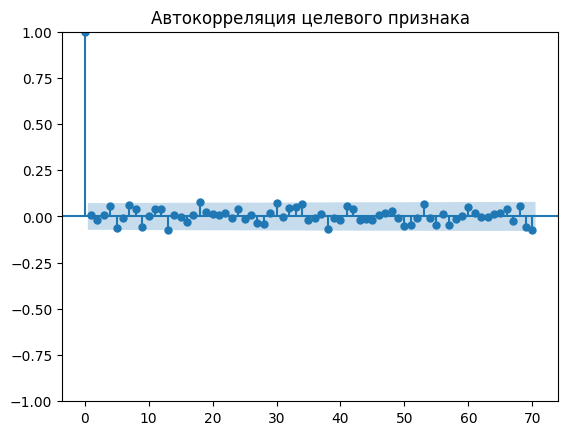

In [18]:
plot_acf(df.groupby('Date')['Cash_Demand_Next_Day'].mean(), lags=70, title='Автокорреляция целевого признака')
plt.show()

Коэффициенты: [ 1.00930708e+00 -7.45178559e-01  7.22715796e+03]
Свободный член: -335.9198798311918
count    5.658000e+03
mean     3.266337e-13
std      6.224024e+03
min     -1.860234e+04
25%     -4.708239e+03
50%      5.670773e+01
75%      4.738407e+03
max      1.892755e+04
Name: Cash_Demand_Next_Day, dtype: float64
Коэффициент детерминации: 0.8626989585717797


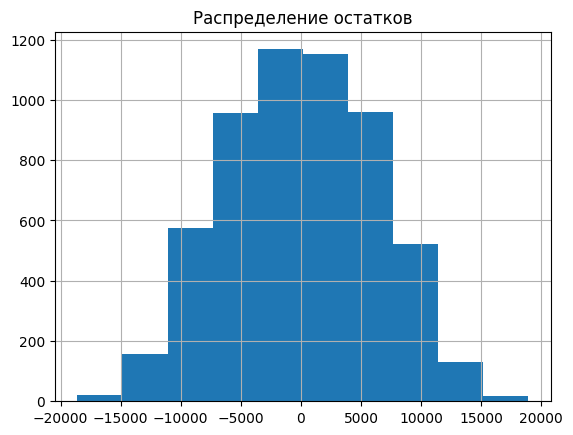

In [19]:
X = df[['Total_Withdrawals', 'Total_Deposits', 'Special_Event_Flag']]
y = df['Cash_Demand_Next_Day']
model = LinearRegression()
model.fit(X, y)
print('Коэффициенты:', model.coef_)
print('Свободный член:', model.intercept_)
print((y - model.predict(X)).describe())
print('Коэффициент детерминации:', model.score(X, y))
(y - model.predict(X)).hist()
plt.title('Распределение остатков')
plt.show()

***Пояснение:*** в предыдущей ячейке я проверял синтетическое происхождение датасета. Это подтверждается тем, что коэффициент детерминации получился 0.86, то есть всего 3 столбца датасета объясняют 86% целевой переменной, а также тем, что коэффициент для столбца 'Total_Withdrawals' почти равен единице (1.009), что нехарактерно для реальных данных. Данные наблюдения являются очень сильными аргументами в пользу синтетичности датасета, а также указывают на то, что целевое не является независимой величиной. Ещё можно обратить внимание на характеристики остатков: медиана (56.7 при разбросе 6224, то есть 0.9%), симметричные перцентили.

**Вывод:** исходя из исследовательского анализа, эти данные с очень большой вероятностью являются синтетическими. Вот причины такого вывода:
1. Распределение целевого признака по локациям и по времени суток идентичны между собой, кроме небольшой разницы в размере усов.
2. Каждый банкомат за всё время находился во всех 5 локациях.
3. Стандартное отклонение и среднее целевого признака, сгруппированное по дням недели, практически не отличаются между собой.
4. На примере банкомата `ATM_0001` можно увидеть, что локации банкоматов могут меняться в течение дня, что выглядит нелогично, даже для мобильных банкоматов. Также на примере двух строк с датой `2022-03-05` можно видеть, что значение столбца `Previous_Day_Cash_Level` (Остаток наличных с предыдущего дня) отличается, хотя это невозможно на реальных данных.

Также исходя из исследовательского анализа, была выдвинута гипотеза об отсутствии временной структуры. На это указывают следующие наблюдения:
1. Корреляция есть только между целевым признаком и операционными показателями (`Total_Withdrawals` и `Total_Deposits`).
2. Отсутствие тренда, сезонности и автокорреляции.

Также было установлено, что датасет охватывает временной диапазон в 731 день в общем. На каждый банкомат в среднем приходится по 113 записей, при этом выявлены нерегулярные пропуски в датах, несколько записей для одного банкомата за один день. Отсюда следует, что отсутствие временной структуры невозможно отличить от простой нехватки данных. 

Для проверки ранее выдвинутой гипотезы будут проведены 5 экспериментов с моделями машинного обучения:
1. Использование агрегированных данных для проверки наличия временной структуры на горизонт 14 дней.
2. Использование агрегированных данных для прогноза на 1 день вперёд, чтобы понять, дело в горизонте прогноза или в отсутствии временной структуры.
3. Прогноз на 14 дней по неагрегированным данным для отдельных банкоматов, чтобы проверить исходную постановку задачи из ТЗ.
4. Прогноз суммарного дневного спроса на наличные на горизонте 14 дней.
5. Прогноз на 1 день вперёд с операционными признаками (`Total_Withdrawals` и `Total_Deposits`), которые при прогнозе на 14 дней будут недоступны, для сравнения с моделями, обученными без этих признаков.

Результаты всех экспериментов будут сравниваться с baseline моделями (константной, наивной и сезонно-наивной) для оценки того, даёт ли модель прирост относительно тривиального предсказания. Гипотеза считается подтверждённой, если модели машинного обучения не превзойдут baseline модели.

### Машинное обучение

#### Написание функции для проведения экспериментов

In [20]:
def smape(y_test, pred):
    numerator = 2 * np.abs(pred - y_test)
    denominator = (np.abs(y_test) + np.abs(pred))
    ratio = np.where(denominator > 0, numerator / denominator, 0)
    return 1 / len(y_test) * np.sum(ratio) * 100

In [21]:
def rmsse(y_test, y_train, pred):
    return ((1 / len(y_test) * np.sum((y_test - pred)**2)) / (1 / (len(y_train) - 1) * np.sum((y_train.diff().dropna())**2)))**0.5

In [22]:
def experiment(df, step=1, operational_indicators=False, func=None, splits=5):
    # аггрегирование датасета, если нужно
    if func in ('mean', 'sum'):
        agg_dict = {
            'Cash_Demand_Next_Day': func,
            'Holiday_Flag': 'max',
            'Special_Event_Flag': 'max'
        }
        if operational_indicators:
            agg_dict['Total_Deposits'] = 'mean'
            agg_dict['Total_Withdrawals'] = 'mean'
        df = df.groupby('Date').agg(agg_dict).reset_index()
    else:
        df = df.drop(['Day_of_Week'], axis=1).reset_index(drop=True)
        if not operational_indicators:
            df = df.drop(['Total_Deposits', 'Total_Withdrawals'], axis=1)
    df = df.sort_values('Date').reset_index(drop=True)
    # создание календарных признаков
    df['target_date'] = df['Date'] + pd.Timedelta(days=1)
    df['dayofweek'] = df['target_date'].dt.dayofweek
    df['month'] = df['target_date'].dt.month
    df['is_weekend'] = (df['target_date'].dt.dayofweek >= 5).astype(int)
    df['dayofyear'] = df['target_date'].dt.dayofyear
    df['day'] = df['target_date'].dt.day
    # разбиение на выборки
    tscv = TimeSeriesSplit(n_splits=splits, test_size=step)
    rmsse_c = []
    rmsse_n = []
    rmsse_ns = []
    rmsse_lr = []
    rmsse_lgbm = []
    smape_c = []
    smape_n = []
    smape_ns = []
    smape_lr = []
    smape_lgbm = []
    if func is None:
        y = df[['Date', 'Cash_Demand_Next_Day']]
        X = df.drop(['Cash_Demand_Next_Day', 'Date', 'target_date', 'Weather_Condition', 'Location_Type', 'Time_of_Day', 'ATM_ID'], axis=1)
        dates = np.sort(df['Date'].unique())
        for train_idx, test_idx in tscv.split(dates):
            train_mask = df['Date'].isin(dates[train_idx])
            X_train = X[train_mask]
            y_train = y[train_mask]
            last_train = y_train.groupby('Date').mean().iloc[-1]
            y_train = y_train.drop(['Date'], axis=1)
            test_mask = df['Date'].isin(dates[test_idx])
            X_test = X[test_mask]
            y_test = y[test_mask]
            y_test = y_test.drop(['Date'], axis=1).squeeze()
            # инициация моделей
            model_lr = LinearRegression()
            model_lr.fit(X_train, y_train)
            pred_lr = model_lr.predict(X_test).flatten()
            model_lgbm = LGBMRegressor(random_state=42, verbose=-1)
            model_lgbm.fit(X_train, y_train)
            pred_lgbm = model_lgbm.predict(X_test)
            const = np.full(len(y_test), y_train.mean())
            naive = np.full(len(y_test), last_train)
            # подсчёт метрик
            rmsse_lr.append(float(rmsse(y_test, y_train, pred_lr)))
            rmsse_lgbm.append(float(rmsse(y_test, y_train, pred_lgbm)))            
            rmsse_c.append(float(rmsse(y_test, y_train, const)))
            rmsse_n.append(float(rmsse(y_test, y_train, naive)))
            rmsse_ns.append(np.nan)
            smape_lr.append(float(smape(y_test, pred_lr)))
            smape_lgbm.append(float(smape(y_test, pred_lgbm)))            
            smape_c.append(float(smape(y_test, const)))
            smape_n.append(float(smape(y_test, naive)))
            smape_ns.append(np.nan)
        # вывод результатов
        print('RMSSE константной модели:', sum(rmsse_c) / len(rmsse_c))
        print('RMSSE константной модели по фолдам:', rmsse_c)
        print('sMAPE константной модели:', sum(smape_c) / len(smape_c))
        print('sMAPE константной модели по фолдам:', smape_c)
        print('RMSSE наивной модели:', sum(rmsse_n) / len(rmsse_n))
        print('RMSSE наивной модели по фолдам:', rmsse_n)
        print('sMAPE наивной модели:', sum(smape_n) / len(smape_n))
        print('sMAPE наивной модели по фолдам:', smape_n)
        print('RMSSE линейной регрессии:', sum(rmsse_lr) / len(rmsse_lr))
        print('RMSSE линейной регрессии по фолдам:', rmsse_lr)
        print('sMAPE линейной регрессии:', sum(smape_lr) / len(smape_lr))
        print('sMAPE линейной регрессии по фолдам:', smape_lr)
        print('RMSSE LGBM регрессора:', sum(rmsse_lgbm) / len(rmsse_lgbm))
        print('RMSSE LGBM регрессора по фолдам:', rmsse_lgbm)
        print('sMAPE LGBM регрессора:', sum(smape_lgbm) / len(smape_lgbm))
        print('sMAPE LGBM регрессора по фолдам:', smape_lgbm)
    else:
        y = df['Cash_Demand_Next_Day']
        X = df.drop(['Cash_Demand_Next_Day', 'Date', 'target_date'], axis=1)
        for train_idx, test_idx in tscv.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

            model_lr = LinearRegression()
            model_lr.fit(X_train, y_train)
            pred_lr = model_lr.predict(X_test)
            model_lgbm = LGBMRegressor(random_state=42, verbose=-1)
            model_lgbm.fit(X_train, y_train)
            pred_lgbm = model_lgbm.predict(X_test)
            const = np.full(len(y_test), y_train.mean())
            naive = np.full(len(y_test), y_train.iloc[-1])
            naive_season = np.tile(y_train.iloc[-7:], np.ceil(step / 7).astype(int))
            naive_season = naive_season[:step]
            
            rmsse_lr.append(float(rmsse(y_test, y_train, pred_lr)))
            rmsse_lgbm.append(float(rmsse(y_test, y_train, pred_lgbm)))
            rmsse_c.append(float(rmsse(y_test, y_train, const)))
            rmsse_n.append(float(rmsse(y_test, y_train, naive)))
            rmsse_ns.append(float(rmsse(y_test, y_train, naive_season)))
            smape_lr.append(float(smape(y_test, pred_lr)))
            smape_lgbm.append(float(smape(y_test, pred_lgbm)))            
            smape_c.append(float(smape(y_test, const)))
            smape_n.append(float(smape(y_test, naive)))
            smape_ns.append(float(smape(y_test, naive_season)))
            
        print('RMSSE константной модели:', sum(rmsse_c) / len(rmsse_c))
        print('RMSSE константной модели по фолдам:', rmsse_c)
        print('sMAPE константной модели:', sum(smape_c) / len(smape_c))
        print('sMAPE константной модели по фолдам:', smape_c)
        print('RMSSE наивной модели:', sum(rmsse_n) / len(rmsse_n))
        print('RMSSE наивной модели по фолдам:', rmsse_n)
        print('sMAPE наивной модели:', sum(smape_n) / len(smape_n))
        print('sMAPE наивной модели по фолдам:', smape_n)
        print('RMSSE сезонно-наивной модели:', sum(rmsse_ns) / len(rmsse_ns))
        print('RMSSE сезонно-наивной модели по фолдам:', rmsse_ns)
        print('sMAPE сезонно-наивной модели:', sum(smape_ns) / len(smape_ns))
        print('sMAPE сезонно-наивной модели по фолдам:', smape_ns)
        print('RMSSE линейной регрессии:', sum(rmsse_lr) / len(rmsse_lr))
        print('RMSSE линейной регрессии по фолдам:', rmsse_lr)
        print('sMAPE линейной регрессии:', sum(smape_lr) / len(smape_lr))
        print('sMAPE линейной регрессии по фолдам:', smape_lr)
        print('RMSSE LGBM регрессора:', sum(rmsse_lgbm) / len(rmsse_lgbm))
        print('RMSSE LGBM регрессора по фолдам:', rmsse_lgbm)
        print('sMAPE LGBM регрессора:', sum(smape_lgbm) / len(smape_lgbm))
        print('sMAPE LGBM регрессора по фолдам:', smape_lgbm)
    return rmsse_c, rmsse_n, rmsse_ns, rmsse_lr, rmsse_lgbm, smape_c, smape_n, smape_ns, smape_lr, smape_lgbm

#### 1 эксперимент — прогноз на агрегированных данных на горизонте 14 дней

In [23]:
res_1 = experiment(df, step=14, splits=5, func='mean')
res_1;

RMSSE константной модели: 0.6586597473621413
RMSSE константной модели по фолдам: [0.6815692915915273, 0.8243986828530134, 0.6861134773943811, 0.375464372489258, 0.7257529124825264]
sMAPE константной модели: 11.141605532338554
sMAPE константной модели по фолдам: [12.737973411450998, 12.626988416172477, 12.22286759536884, 5.710056244038033, 12.41014199466242]
RMSSE наивной модели: 0.7341007960257988
RMSSE наивной модели по фолдам: [0.7001095963429143, 0.8946042344293245, 0.8112663904921795, 0.4284568185729795, 0.8360669402915961]
sMAPE наивной модели: 11.993631896365349
sMAPE наивной модели по фолдам: [13.000448900770387, 10.54215193166151, 14.529536778379448, 7.354130073038859, 14.54189179797654]
RMSSE сезонно-наивной модели: 0.9947993872357875
RMSSE сезонно-наивной модели по фолдам: [0.9771553559399464, 1.0323237818574387, 1.4637280784892435, 0.6596953557237523, 0.8410943641685565]
sMAPE сезонно-наивной модели: 16.613441459567493
sMAPE сезонно-наивной модели по фолдам: [16.344356858399

#### 2 эксперимент — прогноз на агрегированных данных на горизонте 1 дня

In [24]:
res_2 = experiment(df, step=1, splits=30, func='mean')
res_2;

RMSSE константной модели: 0.42819213847653814
RMSSE константной модели по фолдам: [0.694431174928113, 0.19540588599878128, 0.02597716064526937, 0.16360495312747694, 0.056894052495590215, 0.7626414375250592, 0.15022914191151118, 0.024792703607176014, 0.2330181616151869, 0.8988115509351345, 0.496026510617181, 0.16666292923124518, 0.1236702459688437, 0.2612306001289937, 0.10207056164363244, 0.35295768626231555, 0.17160160185253548, 0.26178910328694843, 0.5301165617566115, 0.5895085834741036, 0.02372151025806292, 1.024003587667641, 0.6159025163785652, 0.1463087021024124, 1.5039610119362643, 0.25308648675872847, 1.0081940402762823, 0.7324674136973784, 0.1303995695986669, 1.1462787086104327]
sMAPE константной модели: 9.048244684333456
sMAPE константной модели по фолдам: [13.560615002927054, 4.008634367901238, 0.5420097351126624, 3.4799943177248056, 1.195830758356675, 14.749152432557041, 3.185178909830565, 0.5160443292864455, 4.9803098494728735, 20.668399846867658, 9.82861441104539, 3.4155077

#### 3 эксперимент — прогноз на неагрегированных данных на горизонте 14 дней

In [25]:
res_3 = experiment(df, step=14, splits=5)
res_3;

RMSSE константной модели: 0.7093986786985267
RMSSE константной модели по фолдам: [0.7316668477150512, 0.724401540859853, 0.723741145236561, 0.629337795112137, 0.7378460645690312]
sMAPE константной модели: 34.17079950212748
sMAPE константной модели по фолдам: [34.41899824656805, 35.94655379372323, 35.91547777891274, 30.09386458750273, 34.47910310393065]
RMSSE наивной модели: 0.7200047926510333
RMSSE наивной модели по фолдам: [0.7342959642676169, 0.7296002178385256, 0.7488347370899945, 0.6334761880759198, 0.7538168559831095]
sMAPE наивной модели: 34.881374061629465
sMAPE наивной модели по фолдам: [34.66671125289195, 35.82985726350715, 38.51212705430797, 30.177913348817526, 35.22026138862273]
RMSSE линейной регрессии: 0.6974229805912124
RMSSE линейной регрессии по фолдам: [0.7228059412862538, 0.7148583748525638, 0.712358283115156, 0.6245116482195464, 0.7125806554825418]
sMAPE линейной регрессии: 33.9714715189109
sMAPE линейной регрессии по фолдам: [34.261498419335474, 36.00827653756005, 3

#### 4 эксперимент — прогноз суммарного спроса на горизонте 14 дней

In [26]:
res_4 = experiment(df, step=14, splits=5, func='sum')
res_4;

RMSSE константной модели: 0.6854536914416001
RMSSE константной модели по фолдам: [0.7388219478487784, 0.5845345356893823, 0.649413852995493, 0.6401451911414826, 0.8143529295328639]
sMAPE константной модели: 30.40408176908307
sMAPE константной модели по фолдам: [35.003968980893816, 26.275989791854766, 30.92571077983694, 25.92173819284841, 33.89300109998141]
RMSSE наивной модели: 0.855701064053313
RMSSE наивной модели по фолдам: [0.9071803230161888, 0.7542425604258025, 0.6490093392822649, 0.6751265283360038, 1.2929465692063051]
sMAPE наивной модели: 35.03747686770831
sMAPE наивной модели по фолдам: [33.40526550483383, 35.37494323867029, 30.90121374133068, 28.573166127329365, 46.932795726377364]
RMSSE сезонно-наивной модели: 0.8299737165691038
RMSSE сезонно-наивной модели по фолдам: [0.8737616071073064, 0.744485802505323, 0.8101802859109515, 0.918413983589923, 0.8030269037320155]
sMAPE сезонно-наивной модели: 38.66507114705435
sMAPE сезонно-наивной модели по фолдам: [39.97913110523319, 36

#### 5 эксперимент — прогноз на агрегированных данных с операционными признаками на горизонте 1 день

In [27]:
res_5 = experiment(df, step=1, splits=30, func='mean', operational_indicators=True)
res_5;

RMSSE константной модели: 0.42819213847653814
RMSSE константной модели по фолдам: [0.694431174928113, 0.19540588599878128, 0.02597716064526937, 0.16360495312747694, 0.056894052495590215, 0.7626414375250592, 0.15022914191151118, 0.024792703607176014, 0.2330181616151869, 0.8988115509351345, 0.496026510617181, 0.16666292923124518, 0.1236702459688437, 0.2612306001289937, 0.10207056164363244, 0.35295768626231555, 0.17160160185253548, 0.26178910328694843, 0.5301165617566115, 0.5895085834741036, 0.02372151025806292, 1.024003587667641, 0.6159025163785652, 0.1463087021024124, 1.5039610119362643, 0.25308648675872847, 1.0081940402762823, 0.7324674136973784, 0.1303995695986669, 1.1462787086104327]
sMAPE константной модели: 9.048244684333456
sMAPE константной модели по фолдам: [13.560615002927054, 4.008634367901238, 0.5420097351126624, 3.4799943177248056, 1.195830758356675, 14.749152432557041, 3.185178909830565, 0.5160443292864455, 4.9803098494728735, 20.668399846867658, 9.82861441104539, 3.4155077

### Интерпретация моделей

In [28]:
agg_dict = {
    'Cash_Demand_Next_Day': 'mean',
    'Holiday_Flag': 'max',
    'Special_Event_Flag': 'max'
}
df_copy = df.groupby('Date').agg(agg_dict).reset_index()
df_copy = df_copy.sort_values('Date').reset_index(drop=True)
df_copy['target_date'] = df_copy['Date'] + pd.Timedelta(days=1)
df_copy['dayofweek'] = df_copy['target_date'].dt.dayofweek
df_copy['month'] = df_copy['target_date'].dt.month
df_copy['is_weekend'] = (df_copy['target_date'].dt.dayofweek >= 5).astype(int)
df_copy['dayofyear'] = df_copy['target_date'].dt.dayofyear
df_copy['day'] = df_copy['target_date'].dt.day

X = df_copy.drop(['Cash_Demand_Next_Day', 'Date', 'target_date'], axis=1)
y = df_copy['Cash_Demand_Next_Day']
model_lgbm = LGBMRegressor(random_state=42)
model_lgbm.fit(X, y)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


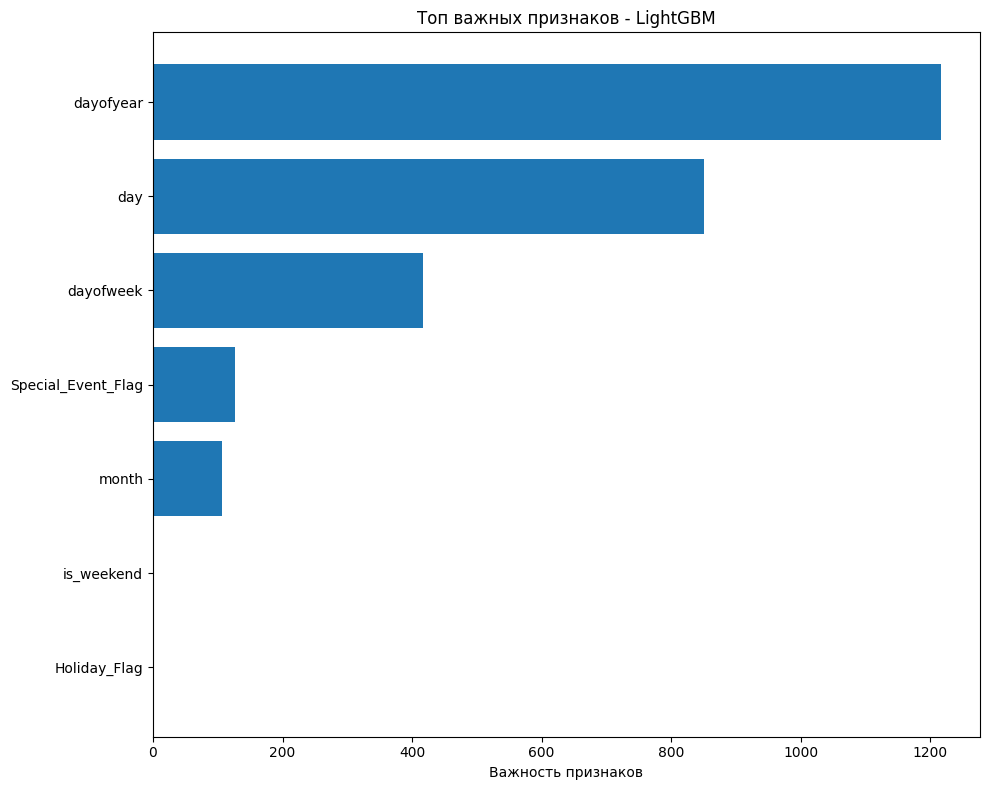

In [29]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': model_lgbm.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Важность признаков')
plt.title('Топ важных признаков - LightGBM')
plt.tight_layout()
plt.show()

2022-01-17 00:00:00


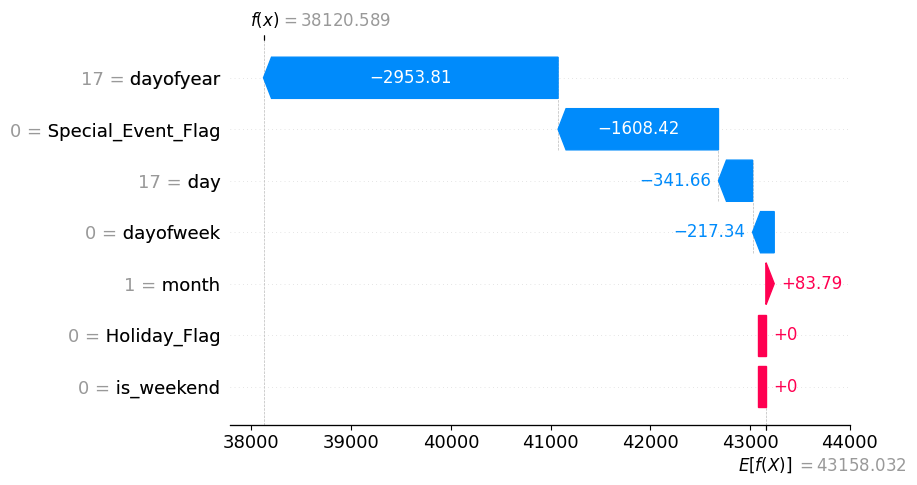

2022-01-03 00:00:00


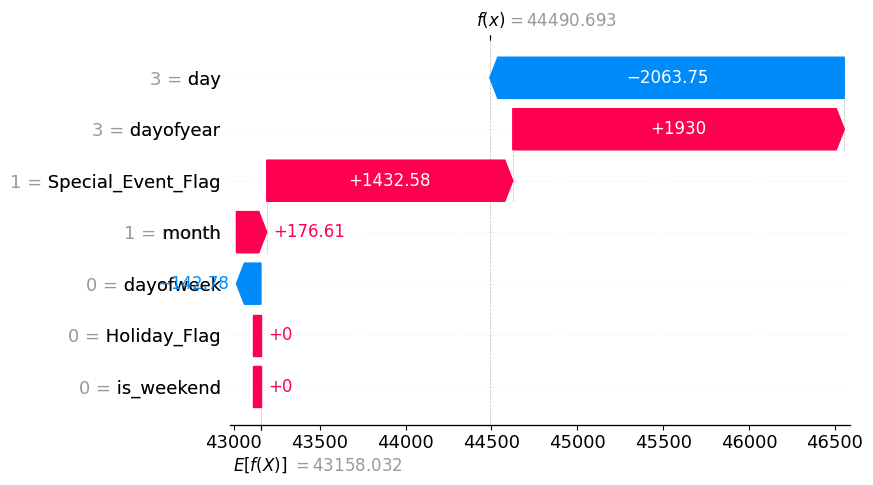

In [30]:
explainer = shap.TreeExplainer(model_lgbm)
monday = X[(X['dayofweek'] == 0) & (X['Special_Event_Flag'] == 0) & (X['Holiday_Flag'] == 0)].index
shap_values = explainer(X.loc[monday])
print(df_copy.loc[monday[0], 'target_date'])
shap.plots.waterfall(shap_values[0])
special_day = X[(X['Special_Event_Flag'] == 1) & (X['Holiday_Flag'] == 0)].index
shap_values = explainer(X.loc[special_day])
print(df_copy.loc[special_day[0], 'target_date']) 
shap.plots.waterfall(shap_values[0])

In [31]:
agg_dict_op = {
    'Cash_Demand_Next_Day': 'mean',
    'Holiday_Flag': 'max',
    'Special_Event_Flag': 'max',
    'Total_Withdrawals': 'mean',
    'Total_Deposits': 'mean'
}
df_copy = df.groupby('Date').agg(agg_dict_op).reset_index()
df_copy = df_copy.sort_values('Date').reset_index(drop=True)
df_copy['target_date'] = df_copy['Date'] + pd.Timedelta(days=1)
df_copy['dayofweek'] = df_copy['target_date'].dt.dayofweek
df_copy['month'] = df_copy['target_date'].dt.month
df_copy['is_weekend'] = (df_copy['target_date'].dt.dayofweek >= 5).astype(int)
df_copy['dayofyear'] = df_copy['target_date'].dt.dayofyear
df_copy['day'] = df_copy['target_date'].dt.day

X_op = df_copy.drop(['Cash_Demand_Next_Day', 'Date', 'target_date'], axis=1)
y_op = df_copy['Cash_Demand_Next_Day']
model_lgbm_op = LGBMRegressor(random_state=42)
model_lgbm_op.fit(X_op, y_op)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


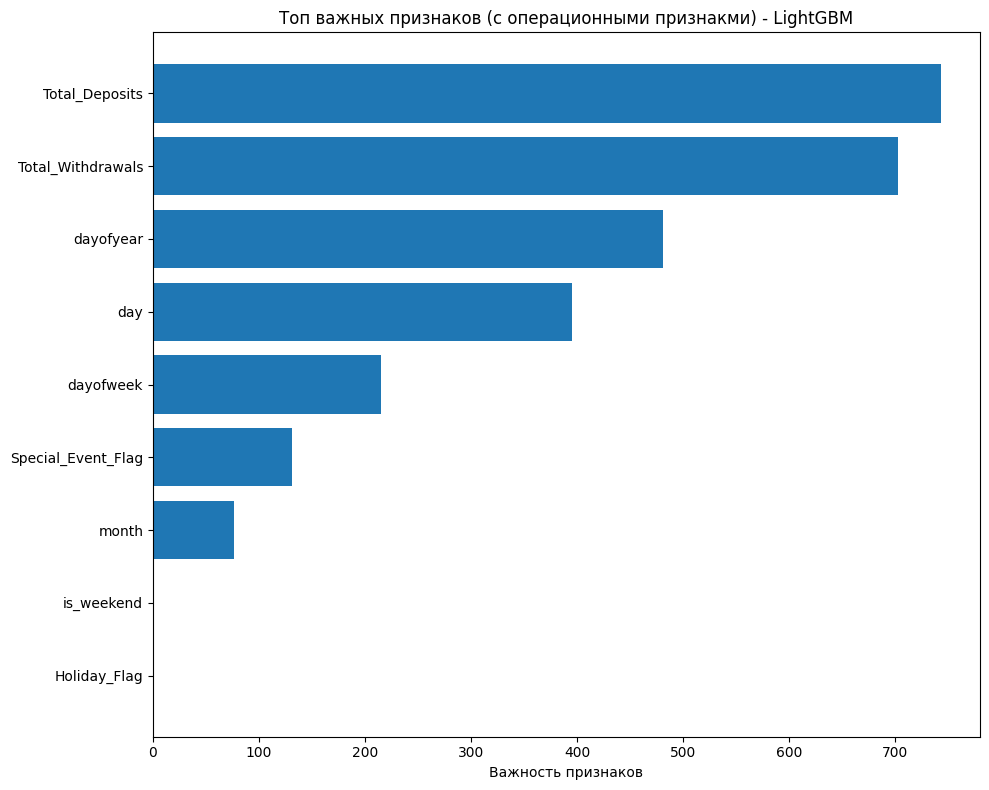

In [32]:
importance_df = pd.DataFrame({
    'feature': X_op.columns,
    'importance': model_lgbm_op.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Важность признаков')
plt.title('Топ важных признаков (с операционными признакми) - LightGBM')
plt.tight_layout()
plt.show()

2022-01-17 00:00:00


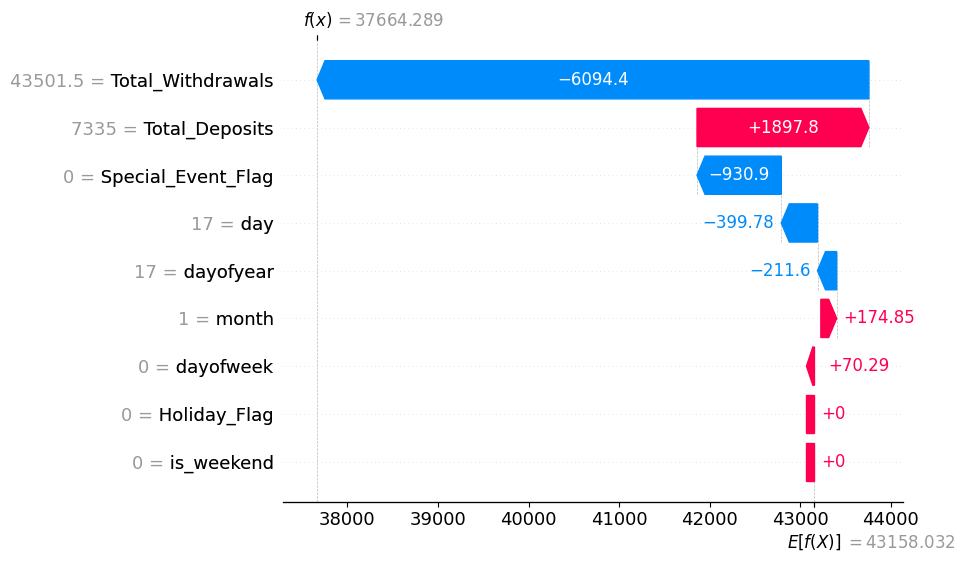

2022-01-03 00:00:00


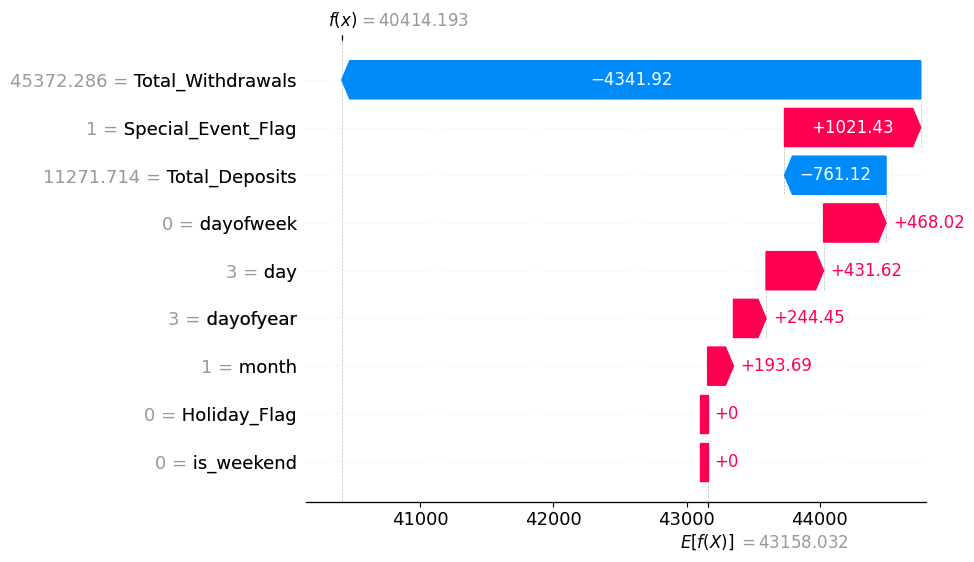

In [33]:
explainer_op = shap.TreeExplainer(model_lgbm_op)
monday_op = X_op[(X_op['dayofweek'] == 0) & (X_op['Special_Event_Flag'] == 0) & (X_op['Holiday_Flag'] == 0)].index
shap_values_op = explainer_op(X_op.loc[monday_op])
print(df_copy.loc[monday_op[0], 'target_date'])
shap.plots.waterfall(shap_values_op[0])
special_day_op = X_op[(X_op['Special_Event_Flag'] == 1) & (X_op['Holiday_Flag'] == 0)].index
shap_values_op = explainer_op(X_op.loc[special_day_op])
print(df_copy.loc[special_day_op[0], 'target_date'])
shap.plots.waterfall(shap_values_op[0])

### Сводные таблицы по результатам 5 экспериментов

In [34]:
data_rmsse = [[round(sum(i) / len(i), 3) for i in j[:5]] for j in [res_1, res_2, res_3, res_4, res_5]]
index_rmsse = ['агрегат, 14 дней', 'агрегат, 1 день', 'отдельные банкоматы, 14 дней', 'сумма, 14 дней', 'агрегат с операционными признаками, 1 день']
columns_rmsse = ['Константная модель', 'Наивная модель', 'Сезонно-наивная модель', 'Линейная регрессия', 'LGBM']
results_rmsse = pd.DataFrame(data=data_rmsse, index=index_rmsse, columns=columns_rmsse)
results_rmsse = results_rmsse.fillna('-')
print('Сводная таблица с метрикой RMSSE')
display(results_rmsse)
data_smape = [[round(sum(i) / len(i), 3) for i in j[5:]] for j in [res_1, res_2, res_3, res_4, res_5]]
index_smape = ['агрегат, 14 дней', 'агрегат, 1 день', 'отдельные банкоматы, 14 дней', 'сумма, 14 дней', 'агрегат с операционными признаками, 1 день']
columns_smape = ['Константная модель', 'Наивная модель', 'Сезонно-наивная модель', 'Линейная регрессия', 'LGBM']
results_smape = pd.DataFrame(data=data_smape, index=index_smape, columns=columns_smape)
results_smape = results_smape.fillna('-')
print('Сводная таблица с метрикой sMAPE')
results_smape

Сводная таблица с метрикой RMSSE


,Константная модель,Наивная модель,Сезонно-наивная модель,Линейная регрессия,LGBM
"агрегат, 14 дней",0.659,0.734,0.995,0.634,0.706
"агрегат, 1 день",0.428,0.707,0.631,0.409,0.485
"отдельные банкоматы, 14 дней",0.709,0.720,-,0.697,0.729
"сумма, 14 дней",0.685,0.856,0.83,0.648,0.687
"агрегат с операционными признаками, 1 день",0.428,0.707,0.631,0.190,0.246


Сводная таблица с метрикой sMAPE


,Константная модель,Наивная модель,Сезонно-наивная модель,Линейная регрессия,LGBM
"агрегат, 14 дней",11.142,11.994,16.613,10.708,12.218
"агрегат, 1 день",9.048,15.039,13.507,8.655,10.169
"отдельные банкоматы, 14 дней",34.171,34.881,-,33.971,35.040
"сумма, 14 дней",30.404,35.037,38.665,28.783,29.977
"агрегат с операционными признаками, 1 день",9.048,15.039,13.507,3.973,5.161


***Пояснение:*** сезонно-наивный прогноз не рассчитывался для неагрегированных данных, поскольку на одну дату приходится несколько записей и понятие «значение неделю назад» для отдельной строки не определено.

**Итоговый вывод:** в экспериментах 1-4 модели не лучше baseline, поскольку небольшие превосходства моделей над baseline являются незначительными на фоне разброса метрик по фолдам. Эксперимент 5 же показывает, что операционные признаки (`Total_Withdrawals` и `Total_Deposits`) сильно влияют на предсказания модели, причём эти признаки в реальных условиях, с горизонтом прогноза 14 дней, будут недоступны. 

В таблице со sMAPE также можно заметить высокие показатели в 3 и 4 экспериментах. В 3 эксперименте прогноз строится по отдельным записям, а не по дневным средним, поэтому в метрику попадает разброс между банкоматами. В 4 эксперименте это объясняется различным количеством записей в день (от 1 до 16 записей), из-за чего суммарный спрос отражает не спрос, а число наблюдений. Улучшение метрики линейной регрессии в эксперименте 5 (с 0.634 до 0.190) объясняется не найденной закономерностью, а тем, что целевое вычисляется по формуле из операционных признаков.

Исходя из графиков feature importance и SHAP можно выделить 3 момента:
1. `Holiday_Flag` и `is_weekend` не влияют на предсказания вообще. То есть праздники и выходные не отражаются на спросе, что для реальных банкоматных данных невозможно.
2. Основной вклад в модели без операционных признаков дают `dayofyear` и `day` (номер дня в году и число), то есть признаки с наибольшим числом значений. Это с большой вероятностью означает подгонку под обучающие даты, а не найденную закономерность.
3. При добавлении операционных признаков они немедленно вытесняют календарные с верхних позиций, а метрика улучшается в 2 раза. Это подтверждает, что целевое определяется величинами той же строки, а не временной динамикой.

Все эти 3 пункта подтверждают гипотезу о том, что целевой признак сформирован искусственно и построчно. Также стоит упомянуть, что LightGBM выдавал предупреждения «no further splits with positive gain» на данных без операционных признаков, то есть часто не находил разбиений, улучшающих предсказание. 

В заключение, можно сказать, что гипотеза об отсутствии временной структуры подтверждена всеми пятью экспериментами; это согласуется с результатами EDA, показавшими, что датасет синтетический и целевая переменная вычисляется из признаков той же строки; следовательно, прогнозирование на горизонт 14 дней на этих данных невозможно принципиально, а не вследствие ограничений использованных методов.